# Práctica 1 — Ejercicio 1: Tiempo de exposición y bacterias sobrevivientes

En un análisis de calidad de un producto alimenticio de un determinado laboratorio se desea conocer la relación entre el **tiempo de exposición** (en segundos), de una misma cantidad de producto, a una temperatura de 180° y el **número de bacterias sobrevivientes**. Para ello se realizó un experimento en 12 observaciones de diferentes tiempos de exposición donde se observó la cantidad de bacterias sobrevivientes.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
# Cargar los datos
df = pd.read_csv("../Datasets/Parte_1/bacterias.csv", sep=";")
df.columns = df.columns.str.strip()
print(df)
print()
print(df[["bacterias_vivas", "segundos"]].describe())

     ID  bacterias_vivas  segundos
0    85               16        11
1   125               50         6
2   106               71         5
3   118               11        12
4    72               95         3
5    19              175         1
6    65               31         8
7    69               82         4
8    74              108         2
9   101               49         7
10   57               17        10
11   94               28         9

       bacterias_vivas   segundos
count        12.000000  12.000000
mean         61.083333   6.500000
std          48.257752   3.605551
min          11.000000   1.000000
25%          25.250000   3.750000
50%          49.500000   6.500000
75%          85.250000   9.250000
max         175.000000  12.000000


## Análisis exploratorio

> **Proponga un análisis exploratorio de los datos y comente la relación que se puede observar entre las variables. ¿Es posible ajustar un modelo de regresión simple entre estas variables?**

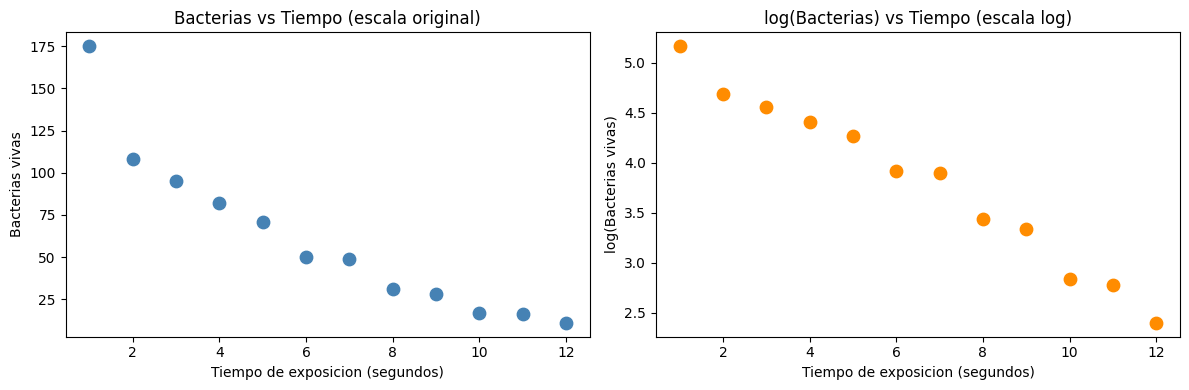

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["segundos"], df["bacterias_vivas"], color="steelblue", s=80)
axes[0].set_xlabel("Tiempo de exposicion (segundos)")
axes[0].set_ylabel("Bacterias vivas")
axes[0].set_title("Bacterias vs Tiempo (escala original)")

# Transformacion logaritmica
df["log_bacterias"] = np.log(df["bacterias_vivas"])

axes[1].scatter(df["segundos"], df["log_bacterias"], color="darkorange", s=80)
axes[1].set_xlabel("Tiempo de exposicion (segundos)")
axes[1].set_ylabel("log(Bacterias vivas)")
axes[1].set_title("log(Bacterias) vs Tiempo (escala log)")

plt.tight_layout()
plt.show()

**Observaciones del EDA:**
- En escala original la relacion es claramente no lineal: a medida que aumenta el tiempo de exposicion,
  el numero de bacterias vivas disminuye de forma exponencial.
- Al aplicar la transformacion logaritmica sobre la variable respuesta, la relacion se vuelve
  aproximadamente lineal, lo que sugiere un modelo log-lineal de la forma:

$$\log(bacterias) = \beta_0 + \beta_1 \cdot \text{segundos}$$

**Correlacion:**

In [4]:
r_orig = df["segundos"].corr(df["bacterias_vivas"])
r_log  = df["segundos"].corr(df["log_bacterias"])
print(f"Correlacion de Pearson (escala original): {r_orig:.4f}")
print(f"Correlacion de Pearson (escala log):      {r_log:.4f}")

Correlacion de Pearson (escala original): -0.9324
Correlacion de Pearson (escala log):      -0.9910


## Ajuste del modelo de regresión

> **De ser así, indique cuál sería el modelo propuesto en relación al problema que busca modelizar y ajústelo con las librerías propuestas en clase.**

El modelo propuesto es un modelo log-lineal:

$$\log(bacterias) = \beta_0 + \beta_1 \cdot \text{segundos}$$

Esto equivale, en escala original, a un modelo exponencial:

$$bacterias = e^{\beta_0} \cdot e^{\beta_1 \cdot t}$$

In [5]:
mod = smf.ols("log_bacterias ~ segundos", data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          log_bacterias   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     550.3
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           4.49e-10
Time:                        18:47:42   Log-Likelihood:                 9.4710
No. Observations:                  12   AIC:                            -14.94
Df Residuals:                      10   BIC:                            -13.97
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3388      0.074     72.054      0.0

In [6]:
b0 = res.params["Intercept"]
b1 = res.params["segundos"]

print(f"Modelo ajustado: log(bacterias) = {b0:.4f} + ({b1:.4f}) * segundos")
print(f"Equivalente: bacterias = {np.exp(b0):.2f} * {np.exp(b1):.4f}^t")
print(f"R2 = {res.rsquared:.4f}")
print(f"Cada segundo adicional multiplica las bacterias por e^({b1:.4f}) = {np.exp(b1):.4f}")

Modelo ajustado: log(bacterias) = 5.3388 + (-0.2362) * segundos
Equivalente: bacterias = 208.26 * 0.7896^t
R2 = 0.9822
Cada segundo adicional multiplica las bacterias por e^(-0.2362) = 0.7896


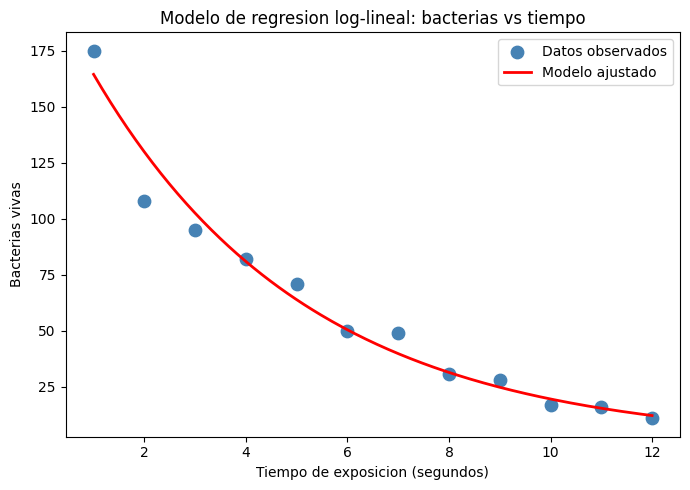

In [7]:
# Grafico del modelo ajustado en escala original
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["segundos"], df["bacterias_vivas"], color="steelblue", s=80, label="Datos observados")
t_seq = np.linspace(df["segundos"].min(), df["segundos"].max(), 200)
ax.plot(t_seq, np.exp(res.predict(pd.DataFrame({"segundos": t_seq}))),
        color="red", lw=2, label="Modelo ajustado")
ax.set_xlabel("Tiempo de exposicion (segundos)")
ax.set_ylabel("Bacterias vivas")
ax.set_title("Modelo de regresion log-lineal: bacterias vs tiempo")
ax.legend()
plt.tight_layout()
plt.show()

## Análisis de residuos

> **Proponga un análisis de residuos. Explique las salidas del modelo (coeficientes, R², y lo que le parezca pertinente).**

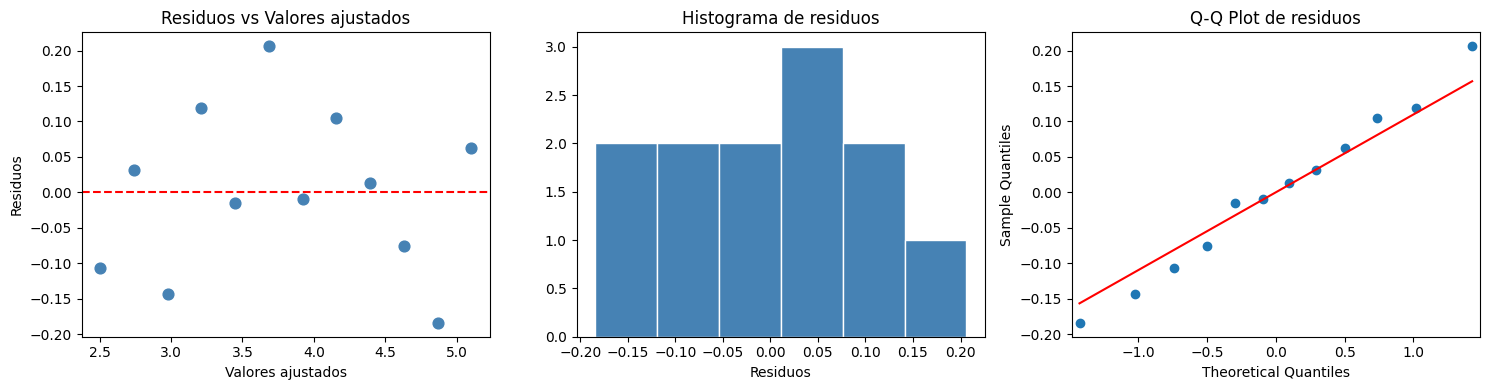

Test de Shapiro-Wilk: W=0.9852, p-valor=0.9968
Conclusion: No se rechaza normalidad (p > 0.05)


In [8]:
residuos = res.resid
fitted   = res.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(fitted, residuos, color="steelblue", s=60)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valores ajustados")
axes[0].set_ylabel("Residuos")
axes[0].set_title("Residuos vs Valores ajustados")

axes[1].hist(residuos, bins=6, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residuos")
axes[1].set_title("Histograma de residuos")

sm.qqplot(residuos, line="s", ax=axes[2])
axes[2].set_title("Q-Q Plot de residuos")

plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f"Test de Shapiro-Wilk: W={stat_sw:.4f}, p-valor={p_sw:.4f}")
print("Conclusion:", "No se rechaza normalidad (p > 0.05)" if p_sw > 0.05
      else "Se rechaza normalidad (p <= 0.05)")

## Conclusiones

> **Escriba sus conclusiones al respecto.**

- La relación entre el tiempo de exposición y el número de bacterias vivas es de tipo exponencial
  decreciente. No es posible ajustar directamente un modelo de regresión lineal simple en escala original.
- Mediante la transformación logarítmica de la variable respuesta se obtuvo un modelo lineal válido:

$$\log(bacterias) = 5.3388 - 0.2362 \cdot \text{segundos}$$

  Equivalente en escala original: $bacterias = 208.26 \cdot 0.7896^t$

- **Interpretación del coeficiente:** Cada segundo adicional de exposición reduce el número de bacterias
  vivas al 78.96% de su valor anterior (una disminución del ~21% por segundo).
- **R² = 0.9822:** El modelo explica el 98.22% de la variabilidad del logaritmo del número de bacterias,
  lo cual indica un ajuste excelente.
- **Residuos:** El test de Shapiro-Wilk (p = 0.9968) indica que los residuos son consistentes con
  la distribución normal. El gráfico de residuos vs valores ajustados no muestra patrones
  sistemáticos, lo que sugiere homocedasticidad y buen ajuste del modelo.